# 01 - Raw Exploration

Open-Meteo feature coverage, missingness, and AQI distribution audit.

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
load_dotenv(str(ROOT / ".env"), override=False)

from src.data.fetch_openmeteo import AIR_QUALITY_HOURLY, WEATHER_HOURLY
from src.utils.mongo_client import get_database

sns.set_theme(style="whitegrid")

db = get_database()
collection = db["aqi_features_rawalpindi"]
data = pd.DataFrame(list(collection.find()))

if data.empty:
    raise ValueError("aqi_features_rawalpindi is empty")

if "_id" in data.columns:
    data = data.drop(columns=["_id"])

data["timestamp"] = pd.to_datetime(data["timestamp"], utc=True, errors="coerce")
data = data.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

data.head()

,timestamp,absolute_humidity,aerosol_optical_depth,alder_pollen,ammonia,apparent_temperature,aqi_change_rate_1h,aqi_change_rate_3h,aqi_change_rate_6h,aqi_trend_slope_6h,...,wind_speed_10m_rolling_min_48h,wind_speed_10m_rolling_min_6h,wind_speed_10m_rolling_std_12h,wind_speed_10m_rolling_std_168h,wind_speed_10m_rolling_std_24h,wind_speed_10m_rolling_std_3h,wind_speed_10m_rolling_std_48h,wind_speed_10m_rolling_std_6h,wind_speed_80m,winter_inversion_flag
0,2025-06-01 00:00:00+00:00,142.680154,0.47,0.0,0.0,23.6,0.0,0.000000,0.0,0.0,...,1.3,1.3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,2025-06-01 01:00:00+00:00,142.324230,0.48,0.0,0.0,22.7,-1.0,0.000000,0.0,-1.0,...,1.3,1.3,0.141421,0.141421,0.141421,0.141421,0.141421,0.141421,0.0,0.0
2,2025-06-01 02:00:00+00:00,141.681096,0.48,0.0,0.0,22.2,0.0,0.000000,0.0,-0.5,...,1.3,1.3,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,0.0,0.0
3,2025-06-01 03:00:00+00:00,139.953278,0.48,0.0,0.0,22.2,-1.0,-0.666667,0.0,-0.6,...,0.4,0.4,0.573730,0.573730,0.573730,0.700000,0.573730,0.573730,0.0,0.0
4,2025-06-01 04:00:00+00:00,132.859902,0.48,0.0,0.0,21.9,0.0,-0.333333,0.0,-0.5,...,0.4,0.4,0.605805,0.605805,0.605805,0.850490,0.605805,0.605805,0.0,0.0


In [4]:
missing_weather_columns = sorted(set(WEATHER_HOURLY) - set(data.columns))
missing_air_columns = sorted(set(AIR_QUALITY_HOURLY) - set(data.columns))
required_fields = ["timestamp", "european_aqi", "pm2_5", "pm10"]

coverage = pd.DataFrame(
    {
        "dataset": ["weather", "air_quality", "required_fields"],
        "expected": [len(WEATHER_HOURLY), len(AIR_QUALITY_HOURLY), len(required_fields)],
        "present": [
            len(WEATHER_HOURLY) - len(missing_weather_columns),
            len(AIR_QUALITY_HOURLY) - len(missing_air_columns),
            sum(field in data.columns for field in required_fields),
        ],
        "missing": [
            len(missing_weather_columns),
            len(missing_air_columns),
            sum(field not in data.columns for field in required_fields),
        ],
    }
)

display(coverage)
print("Missing weather columns:", missing_weather_columns or ["None"])
print("Missing air-quality columns:", missing_air_columns or ["None"])

,dataset,expected,present,missing
0,weather,30,28,2
1,air_quality,23,21,2
2,required_fields,4,4,0


Missing weather columns: ['uv_index', 'uv_index_clear_sky']
Missing air-quality columns: ['uv_index', 'uv_index_clear_sky']


,missing_rate
timestamp,0.0
absolute_humidity,0.0
aerosol_optical_depth,0.0
alder_pollen,0.0
ammonia,0.0
apparent_temperature,0.0
aqi_change_rate_1h,0.0
aqi_change_rate_3h,0.0
aqi_change_rate_6h,0.0
aqi_trend_slope_6h,0.0


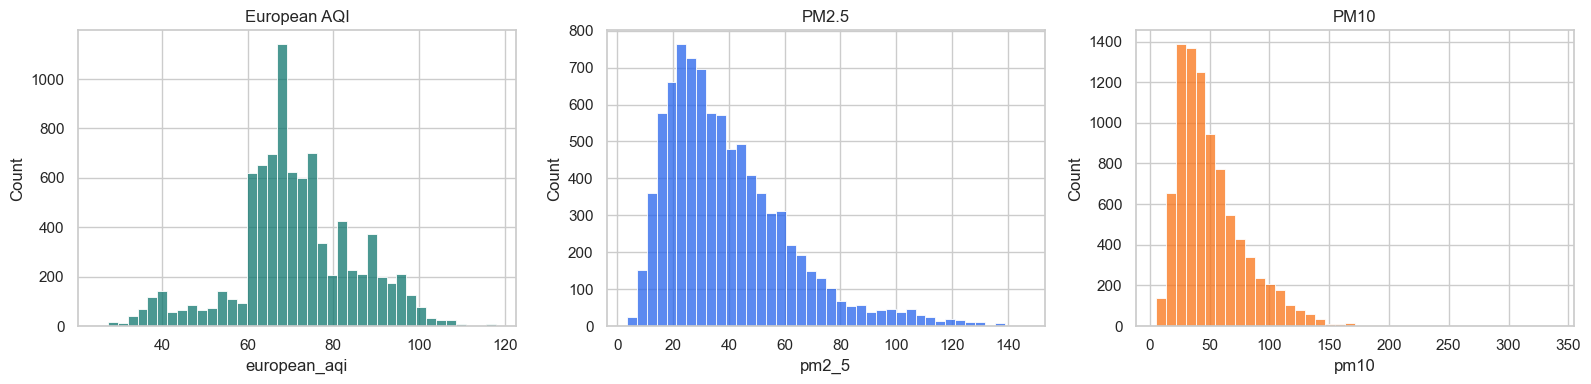

In [5]:
missingness = data.isna().mean().sort_values(ascending=False).rename("missing_rate").to_frame()
top_missing = missingness.head(20)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(data["european_aqi"].dropna(), bins=40, ax=axes[0], color="#0f766e")
axes[0].set_title("European AQI")
sns.histplot(data["pm2_5"].dropna(), bins=40, ax=axes[1], color="#2563eb")
axes[1].set_title("PM2.5")
sns.histplot(data["pm10"].dropna(), bins=40, ax=axes[2], color="#f97316")
axes[2].set_title("PM10")
plt.tight_layout()

display(top_missing)

/tmp/ipykernel_134834/817318220.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data.assign(month=data["timestamp"].dt.to_period("M").dt.to_timestamp())


,metric,value
0,rows,8784.0
1,expected_hours,8784.0
2,hourly_coverage,1.0
3,gap_count,0.0


,rows,mean_aqi,pm25_mean,pm10_mean
month,,,,
2025-06-01,720,72.120833,39.354583,65.162222
2025-07-01,744,71.346774,40.168011,54.780242
2025-08-01,744,71.313172,39.108737,51.655914
2025-09-01,720,68.270833,36.110833,40.202917
2025-10-01,744,65.916667,33.013038,35.994892
2025-11-01,720,80.069444,50.365694,52.088194
2025-12-01,744,88.155914,60.269624,63.262903
2026-01-01,744,85.314516,56.592473,59.939919
2026-02-01,672,70.991071,38.335417,43.412946


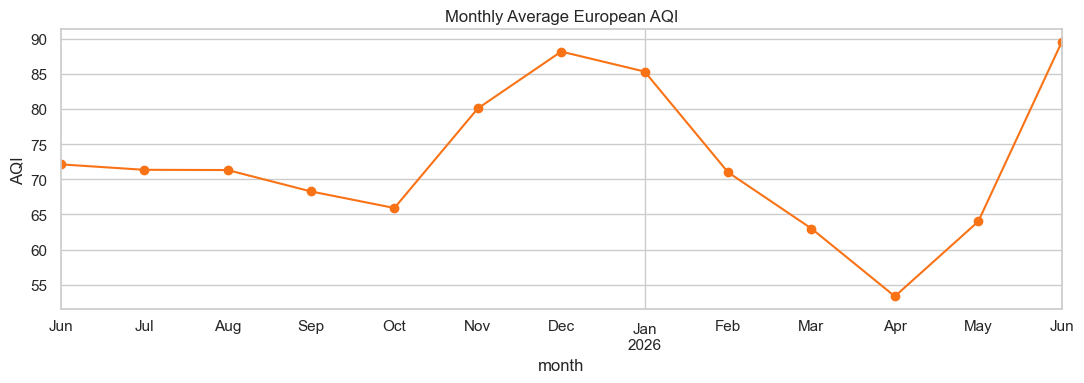

In [10]:

hourly_index = pd.date_range(data["timestamp"].min(), data["timestamp"].max(), freq="h", tz="UTC")
gap_hours = data["timestamp"].diff().dt.total_seconds().div(3600)
gaps = gap_hours[gap_hours > 1].dropna()

monthly = (
    data.assign(month=data["timestamp"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .agg(
        rows=("timestamp", "size"),
        mean_aqi=("european_aqi", "mean"),
        pm25_mean=("pm2_5", "mean"),
        pm10_mean=("pm10", "mean"),
    )
)

fig, ax = plt.subplots(figsize=(11, 4))
monthly["mean_aqi"].plot(kind="line", marker="o", ax=ax, color="#f97316")
ax.set_title("Monthly Average European AQI")
ax.set_ylabel("AQI")
plt.tight_layout()

display(
    pd.DataFrame(
        {
            "metric": ["rows", "expected_hours", "hourly_coverage", "gap_count"],
            "value": [len(data), len(hourly_index), len(data) / len(hourly_index), len(gaps)],
        }
    )
)
display(monthly)

In [11]:
print(f"Rows: {len(data)}")
print(f"Date range: {data['timestamp'].min()} → {data['timestamp'].max()}")
print(f"Columns: {len(data.columns)}")
print(f"AQI range: {data['european_aqi'].min():.1f} – {data['european_aqi'].max():.1f}")
print(f"AQI nulls: {data['european_aqi'].isna().mean():.2%}")

Rows: 8784
Date range: 2025-06-01 00:00:00+00:00 → 2026-06-01 23:00:00+00:00
Columns: 249
AQI range: 25.0 – 118.0
AQI nulls: 0.00%


In [12]:
lag_cols = [c for c in data.columns if "_lag_" in c]
rolling_cols = [c for c in data.columns if "_rolling_" in c]

lag_null = data[lag_cols].isna().mean().sort_values(ascending=False)
print("=== LAG FEATURE NULL RATES (top 20) ===")
print(lag_null.head(20).to_string())

print(f"\n=== ROLLING FEATURE NULL RATES (top 20) ===")
print(data[rolling_cols].isna().mean().sort_values(ascending=False).head(20).to_string())

=== LAG FEATURE NULL RATES (top 20) ===
european_aqi_lag_12h        0.0
european_aqi_lag_168h       0.0
european_aqi_lag_1h         0.0
european_aqi_lag_24h        0.0
european_aqi_lag_2h         0.0
european_aqi_lag_3h         0.0
european_aqi_lag_48h        0.0
european_aqi_lag_6h         0.0
european_aqi_lag_72h        0.0
nitrogen_dioxide_lag_1h     0.0
nitrogen_dioxide_lag_24h    0.0
nitrogen_dioxide_lag_6h     0.0
pm10_lag_168h               0.0
pm10_lag_1h                 0.0
pm10_lag_24h                0.0
pm10_lag_48h                0.0
pm10_lag_6h                 0.0
pm2_5_lag_168h              0.0
pm2_5_lag_1h                0.0
pm2_5_lag_24h               0.0

=== ROLLING FEATURE NULL RATES (top 20) ===
european_aqi_rolling_mean_12h     0.0
european_aqi_rolling_mean_168h    0.0
european_aqi_rolling_mean_24h     0.0
european_aqi_rolling_mean_3h      0.0
european_aqi_rolling_mean_48h     0.0
european_aqi_rolling_mean_6h      0.0
european_aqi_rolling_min_12h      0.0
european_

In [13]:
check = data[["timestamp", "european_aqi", "european_aqi_lag_1h", "european_aqi_rolling_mean_3h"]].tail(48)
print(check.to_string())
print(f"\nlag_1h null rate: {data['european_aqi_lag_1h'].isna().mean():.2%}")
print(f"lag_1h zero rate: {(data['european_aqi_lag_1h'] == 0).mean():.2%}")
print(f"lag_1h correlation with european_aqi: {data['european_aqi'].corr(data['european_aqi_lag_1h']):.4f}")

                     timestamp  european_aqi  european_aqi_lag_1h  european_aqi_rolling_mean_3h
8736 2026-05-31 00:00:00+00:00         108.0                106.0                    106.333333
8737 2026-05-31 01:00:00+00:00         110.0                108.0                    108.000000
8738 2026-05-31 02:00:00+00:00         112.0                110.0                    110.000000
8739 2026-05-31 03:00:00+00:00         114.0                112.0                    112.000000
8740 2026-05-31 04:00:00+00:00         116.0                114.0                    114.000000
8741 2026-05-31 05:00:00+00:00         117.0                116.0                    115.666667
8742 2026-05-31 06:00:00+00:00         117.0                117.0                    116.666667
8743 2026-05-31 07:00:00+00:00         118.0                117.0                    117.333333
8744 2026-05-31 08:00:00+00:00         118.0                118.0                    117.666667
8745 2026-05-31 09:00:00+00:00         1

In [14]:
from src.features.feature_catalog import TOP_FEATURES

available = [f for f in TOP_FEATURES if f in data.columns]
missing_from_data = [f for f in TOP_FEATURES if f not in data.columns]

corr = data[available + ["european_aqi"]].corr()["european_aqi"].drop("european_aqi")
corr_df = corr.abs().sort_values(ascending=False).rename("abs_correlation").to_frame()
corr_df["raw_correlation"] = corr

print(f"Features in TOP_FEATURES missing from data: {missing_from_data}")
print("\n=== FEATURE CORRELATIONS WITH TARGET ===")
display(corr_df)

Features in TOP_FEATURES missing from data: []

=== FEATURE CORRELATIONS WITH TARGET ===


,abs_correlation,raw_correlation
european_aqi_rolling_mean_3h,0.991655,0.991655
european_aqi_rolling_min_3h,0.986903,0.986903
european_aqi_lag_1h,0.985001,0.985001
pm2_5_rolling_mean_12h,0.781417,0.781417
pm10_rolling_mean_24h,0.750873,0.750873
pm10_rolling_mean_48h,0.714145,0.714145
pm2_5_rolling_min_6h,0.657839,0.657839
pm2_5_rolling_mean_6h,0.657837,0.657837
european_aqi_rolling_min_168h,0.644040,0.644040
pm10_rolling_mean_12h,0.643449,0.643449


In [15]:
live_collection = db["aqi_features_live_rawalpindi"]
live_data = pd.DataFrame(list(live_collection.find()))

if "_id" in live_data.columns:
    live_data = live_data.drop(columns=["_id"])

live_data["timestamp"] = pd.to_datetime(live_data["timestamp"], utc=True, errors="coerce")
live_data = live_data.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

print(f"Live collection rows: {len(live_data)}")
print(f"Live date range: {live_data['timestamp'].min()} → {live_data['timestamp'].max()}")

available_live = [f for f in TOP_FEATURES if f in live_data.columns]
missing_live = [f for f in TOP_FEATURES if f not in live_data.columns]
print(f"\nTOP_FEATURES present in live: {len(available_live)}/40")
print(f"Missing from live: {missing_live}")

# Null rates for top 40 in live collection
null_live = live_data[available_live].isna().mean().sort_values(ascending=False)
print("\n=== NULL RATES IN LIVE COLLECTION (top 20) ===")
print(null_live.head(20).to_string())

Live collection rows: 8774
Live date range: 2025-06-01 00:00:00+00:00 → 2026-06-01 13:00:00+00:00

TOP_FEATURES present in live: 40/40
Missing from live: []

=== NULL RATES IN LIVE COLLECTION (top 20) ===
wind_speed_10m_rolling_std_168h         0.0
hour_sin                                0.0
is_day                                  0.0
hour_of_day                             0.0
solar_radiation_category                0.0
european_aqi_rolling_std_168h           0.0
day_of_week_cos                         0.0
hour_cos                                0.0
european_aqi_rolling_std_24h            0.0
european_aqi_rolling_min_168h           0.0
pm10_rolling_mean_24h                   0.0
hour_traffic_weight                     0.0
days_since_last_rain                    0.0
relative_humidity_2m_rolling_min_24h    0.0
pm10_rolling_mean_48h                   0.0
european_aqi_rolling_std_48h            0.0
day_of_week                             0.0
pm10_rolling_mean_12h                   0.0
pm1

In [16]:
gap_hours = data["timestamp"].diff().dt.total_seconds().div(3600)
gaps = gap_hours[gap_hours > 1].dropna()

print(f"Total gaps > 1h: {len(gaps)}")
print(f"Gaps > 24h: {(gaps > 24).sum()}")
print(f"Gaps > 72h: {(gaps > 72).sum()}")
print(f"Largest gap: {gaps.max():.1f} hours")

print("\n=== TOP 10 LARGEST GAPS ===")
top_gaps = gaps.sort_values(ascending=False).head(10)
for idx, hours in top_gaps.items():
    print(f"  At {data.loc[idx, 'timestamp']}  →  {hours:.1f}h gap")

Total gaps > 1h: 0
Gaps > 24h: 0
Gaps > 72h: 0
Largest gap: nan hours

=== TOP 10 LARGEST GAPS ===


In [17]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Persistence baseline: predict t+1..t+72 = last known value
# Seasonal naive: predict same hour from 24h ago
target = data["european_aqi"].astype(float)
horizon = 72
results = []

for name, shift in [("persistence", 1), ("seasonal_naive_24h", 24), ("seasonal_naive_168h", 168)]:
    lagged = target.shift(shift)
    valid = target.iloc[shift:].reset_index(drop=True)
    pred = lagged.iloc[shift:].reset_index(drop=True)
    mask = pred.notna() & valid.notna()
    rmse = np.sqrt(mean_squared_error(valid[mask], pred[mask]))
    mae = (valid[mask] - pred[mask]).abs().mean()
    ss_res = ((valid[mask] - pred[mask]) ** 2).sum()
    ss_tot = ((valid[mask] - valid[mask].mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    results.append({"baseline": name, "rmse": round(rmse, 3), "mae": round(mae, 3), "r2": round(r2, 3)})

display(pd.DataFrame(results))
print("\nYour model RMSE ~12.4 — compare above to see actual uplift over naive baselines")

,baseline,rmse,mae,r2
0,persistence,2.145,0.845,0.977
1,seasonal_naive_24h,9.778,6.855,0.527
2,seasonal_naive_168h,14.384,10.808,-0.023



Your model RMSE ~12.4 — compare above to see actual uplift over naive baselines
